In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
renovables=pd.read_csv("renovables_df.csv")
renovables

,Country,Balance,Time,Product,Value,Unit,Month,Year
0,Colombia,Net Electricity Production,2025-12-01,Electricity,7794.9781,GWh,12,2025
1,Colombia,Net Electricity Production,2025-12-01,Hydro,5530.6545,GWh,12,2025
2,Colombia,Net Electricity Production,2025-12-01,Total Combustible Fuels,1764.6682,GWh,12,2025
3,Colombia,Net Electricity Production,2025-12-01,"Coal, Peat and Manufactured Gases",483.3555,GWh,12,2025
4,Colombia,Net Electricity Production,2025-12-01,Oil and Petroleum Products,287.5943,GWh,12,2025
...,...,...,...,...,...,...,...,...
2341,Colombia,Total Imports,2014-01-01,Electricity,0.0210,GWh,1,2014
2342,Colombia,Total Exports,2014-01-01,Electricity,146.8880,GWh,1,2014
2343,Colombia,Distribution Losses,2014-01-01,Electricity,536.1640,GWh,1,2014
2344,Colombia,Final Consumption (Calculated),2014-01-01,Electricity,5019.6840,GWh,1,2014


In [10]:
renovables.head()
renovables.info()

<class 'pandas.DataFrame'>
RangeIndex: 2346 entries, 0 to 2345
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  2346 non-null   str    
 1   Balance  2346 non-null   str    
 2   Time     2346 non-null   str    
 3   Product  2346 non-null   str    
 4   Value    2346 non-null   float64
 5   Unit     2346 non-null   str    
 6   Month    2346 non-null   int64  
 7   Year     2346 non-null   int64  
dtypes: float64(1), int64(2), str(5)
memory usage: 287.8 KB


In [24]:
renovables.Product.unique()


<ArrowStringArray>
[                                      'Electricity',
                                             'Hydro',
                           'Total Combustible Fuels',
                 'Coal, Peat and Manufactured Gases',
                        'Oil and Petroleum Products',
                                       'Natural Gas',
                            'Combustible Renewables',
                                             'Solar',
 'Total Renewables (Hydro, Geo, Solar, Wind, Other)',
                                              'Wind',
                                     'Not Specified',
                  'Other Combustible Non-Renewables',
                                           'Nuclear',
                                        'Geothermal',
                                  'Other Renewables']
Length: 15, dtype: str

In [32]:
conteo_productos = renovables['Product'].value_counts()
print(conteo_productos)


Product
Electricity                                          768
Hydro                                                144
Total Combustible Fuels                              144
Coal, Peat and Manufactured Gases                    144
Oil and Petroleum Products                           144
Natural Gas                                          144
Combustible Renewables                               144
Solar                                                144
Total Renewables (Hydro, Geo, Solar, Wind, Other)    144
Wind                                                 140
Not Specified                                         92
Other Combustible Non-Renewables                      50
Nuclear                                               48
Geothermal                                            48
Other Renewables                                      48
Name: count, dtype: int64


In [42]:
#creación de una lista con los renovables
lista_renovables = ["Hydro", "Solar","Wind" , "Geothermal", "Combustible Renewables", "Other Renewables"]

In [43]:
#Creación del nuevo dataframe filtrado para los prodcutos renovables
df_solo_renovables = renovables[renovables['Product'].isin(lista_renovables)]
df_solo_renovables.head()

,Country,Balance,Time,Product,Value,Unit,Month,Year
1,Colombia,Net Electricity Production,2025-12-01,Hydro,5530.6545,GWh,12,2025
6,Colombia,Net Electricity Production,2025-12-01,Combustible Renewables,229.6775,GWh,12,2025
7,Colombia,Net Electricity Production,2025-12-01,Solar,479.8602,GWh,12,2025
13,Colombia,Net Electricity Production,2025-12-01,Wind,19.7951,GWh,12,2025
15,Colombia,Net Electricity Production,2025-11-01,Hydro,5373.6740,GWh,11,2025


In [51]:
#Grafico de barras para visualizar la cantidad de cada producto renovable
df_grafica_renovables = df_solo_renovables.groupby('Product')['Value'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

df_grafica_renovables.head(20)

,Product,Value
0,Hydro,654165.0452
1,Combustible Renewables,23138.7185
2,Solar,10373.3818
3,Wind,984.6384
4,Geothermal,0.0000
5,Other Renewables,0.0000


<Figure size 1000x600 with 0 Axes>

C:\Users\Andi Jimenez H\AppData\Local\Temp\ipykernel_19064\1753145135.py:24: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(df_grafica_renovables['Value'].min() * 0.5, df_grafica_renovables['Value'].max() * 3)


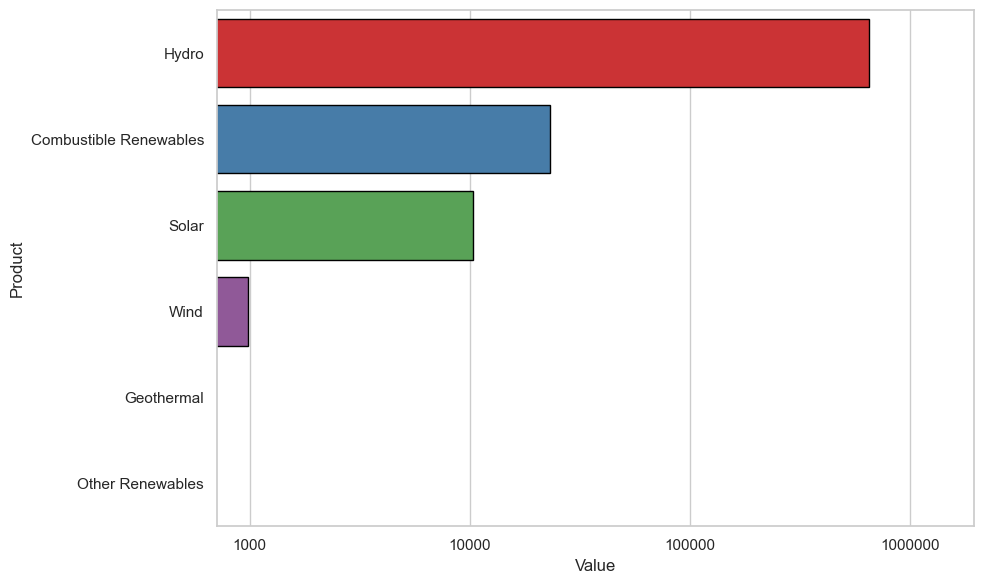

In [72]:

import matplotlib.ticker as ticker # Necesitamos esto para los números "normales"

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

grafico = sns.barplot(
    x="Value", 
    y="Product", 
    data=df_grafica_renovables, 
    hue="Product",    
    palette="Set1",   
    legend=False,     
    edgecolor="black")


#Aplicar una escala logaritmica para mejorar la visualización
plt.xscale("log")

grafico.xaxis.set_major_formatter(ticker.ScalarFormatter())
grafico.xaxis.get_major_formatter().set_scientific(False) # Apaga la notación científica
grafico.xaxis.get_major_formatter().set_useOffset(False)

# Ajustamos el límite para que los números no se corten
plt.xlim(df_grafica_renovables['Value'].min() * 0.5, df_grafica_renovables['Value'].max() * 3)

plt.tight_layout()
plt.show()

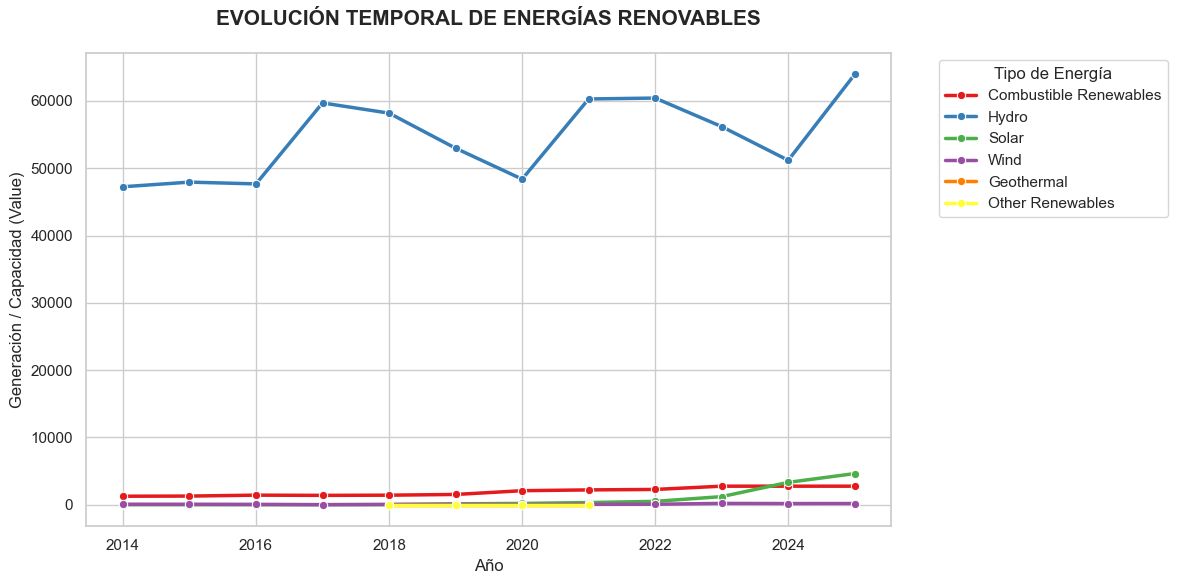

In [75]:
# 1. Preparación de datos: Agrupamos por Año y Producto para sumar el valor
# Asegúrate de que la columna del año se llame 'Year' (o cámbiala por el nombre exacto que tenga)
df_temporal = df_solo_renovables.groupby(['Year', 'Product'])['Value'].sum().reset_index()

# 2. Configuración de la gráfica
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# 3. Creación del gráfico de líneas
# x = El tiempo, y = El valor, hue = Segmentación por tipo de energía
grafico_tiempo = sns.lineplot(
    data=df_temporal, 
    x="Year", 
    y="Value", 
    hue="Product", 
    palette="Set1",      # Colores distintos para cada línea
    linewidth=2.5,       # Líneas un poco más gruesas
    marker='o'           # Puntos en cada año para identificar mejor los datos
)

# 4. Personalización estética
plt.title('EVOLUCIÓN TEMPORAL DE ENERGÍAS RENOVABLES', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Generación / Capacidad (Value)', fontsize=12)

# Colocamos la leyenda fuera del gráfico para que no tape las líneas
plt.legend(title='Tipo de Energía', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Forzar a que el eje X muestre años enteros (sin decimales)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

